# EDA-проект: анализ стоимости Airbnb в европейских городах

## Тема проекта

Цель проекта — понять, как туристу выбрать город, время поездки и тип размещения на Airbnb, чтобы не переплатить.

В проекте анализируются данные по объектам Airbnb в 10 европейских городах отдельно для будних и выходных дней.

## План анализа

1. Загрузить и объединить данные по всем городам.
2. Проверить структуру данных: размеры таблицы, типы переменных, пропуски.
3. Изучить распределение цен и наличие выбросов.
4. Сравнить среднюю и медианную стоимость размещения.
5. Сравнить стоимость Airbnb между городами.
6. Оценить разницу цен между будними и выходными днями.
7. Проанализировать стоимость для разных сценариев поездки: пара, семья, большая группа.
8. Сформулировать выводы для туриста.

### Описание данных

Для каждого объекта указаны переменные:

- `realSum` — стоимость размещения за сутки
- `room_type` — тип комнаты или номера
- `room_shared` — есть комнаты совместного проживания
- `room_private` — есть частные комнаты
- `person_capacity` — максимальное количество постояльцев
- `host_is_superhost` — суперхост ли хозяин
- `multi` — у хоста от 2 до 4 предложений на Airbnb
- `biz` — у хоста более 4 предложений на Airbnb
- `cleanliness_rating` — рейтинг чистоты
- `guest_satisfaction_overall` — общий рейтинг
- `bedrooms` — количество спален
- `dist` — расстояние от центра города
- `metro_dist` — расстояние до ближайшей станции метро
- `lng` — долгота
- `lat` — широта
- `attr_index` — индекс привлекательности района
- `attr_index_norm` — нормализованный индекс привлекательности района
- `rest_index` — индекс ресторанов в районе объекта
- `rest_index_norm` — нормализованный индекс ресторанов в районе объекта

In [87]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

## 1. Загрузить и объединить данные по всем городам.

In [88]:
# Загружаем данные

# функция для удобной загрузки 20 файлов экономией кода
data_path = Path('../data/raw')

def load_airbnb(file_name):
    return pd.read_csv(data_path / f'{file_name}.csv')

In [89]:
# загружаем данные

# город 1 Амстердам
amsterdam_weekdays = load_airbnb('amsterdam_weekdays')  # будни
amsterdam_weekends = load_airbnb('amsterdam_weekends')  # выходные
# город 2 Афины
athens_weekdays = load_airbnb('athens_weekdays')  # будни
athens_weekends = load_airbnb('athens_weekends')  # выходные
# город 3 Барселона
barcelona_weekdays = load_airbnb('barcelona_weekdays')  # будни
barcelona_weekends = load_airbnb('barcelona_weekends')  # выходные
# город 4 Берлин
berlin_weekdays = load_airbnb('berlin_weekdays')  # будни
berlin_weekends = load_airbnb('berlin_weekends')  # выходные
# город 5 Будапешт
budapest_weekdays = load_airbnb('budapest_weekdays')  # будни
budapest_weekends = load_airbnb('budapest_weekends')  # выходные
# город 6 Лиссабон
lisbon_weekdays = load_airbnb('lisbon_weekdays')  # будни
lisbon_weekends = load_airbnb('lisbon_weekends')  # выходные
# город 7 Лондон
london_weekdays = load_airbnb('london_weekdays')  # будни
london_weekends = load_airbnb('london_weekends')  # выходные
# город 8 Париж
paris_weekdays = load_airbnb('paris_weekdays')  # будни
paris_weekends = load_airbnb('paris_weekends')  # выходные
# город 9 Рим
rome_weekdays = load_airbnb('rome_weekdays')  # будни
rome_weekends = load_airbnb('rome_weekends')  # выходные
# город 10 Вена
vienna_weekdays = load_airbnb('vienna_weekdays')  # будни
vienna_weekends = load_airbnb('vienna_weekends')  # выходные

In [90]:
# добавляем в каждый датафрейм колонки города и периода для дальнейшего объединения и различия

def prepare_airbnb_df(df, city, period):
    df['city'] = city
    df['period'] = period
    df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore') # удаляю лишнюю колонку старого индекса

# список городов и периодов для применения функции через цикл
datasets_info = [
    # город 1 Амстердам
    (amsterdam_weekdays, 'amsterdam', 'weekdays'),  # будни
    (amsterdam_weekends, 'amsterdam', 'weekends'),  # выходные

    # город 2 Афины
    (athens_weekdays, 'athens', 'weekdays'),  # будни
    (athens_weekends, 'athens', 'weekends'),  # выходные

    # город 3 Барселона
    (barcelona_weekdays, 'barcelona', 'weekdays'),  # будни
    (barcelona_weekends, 'barcelona', 'weekends'),  # выходные

    # город 4 Берлин
    (berlin_weekdays, 'berlin', 'weekdays'),  # будни
    (berlin_weekends, 'berlin', 'weekends'),  # выходные

    # город 5 Будапешт
    (budapest_weekdays, 'budapest', 'weekdays'),  # будни
    (budapest_weekends, 'budapest', 'weekends'),  # выходные

    # город 6 Лиссабон
    (lisbon_weekdays, 'lisbon', 'weekdays'),  # будни
    (lisbon_weekends, 'lisbon', 'weekends'),  # выходные

    # город 7 Лондон
    (london_weekdays, 'london', 'weekdays'),  # будни
    (london_weekends, 'london', 'weekends'),  # выходные

    # город 8 Париж
    (paris_weekdays, 'paris', 'weekdays'),  # будни
    (paris_weekends, 'paris', 'weekends'),  # выходные

    # город 9 Рим
    (rome_weekdays, 'rome', 'weekdays'),  # будни
    (rome_weekends, 'rome', 'weekends'),  # выходные

    # город 10 Вена
    (vienna_weekdays, 'vienna', 'weekdays'),  # будни
    (vienna_weekends, 'vienna', 'weekends')  # выходные
]

# цикл для присвоения каждому датафрейму колонок города и периода

for df, city, period in datasets_info:
    prepare_airbnb_df(df, city, period) # применяем функцию добавления колонок

In [91]:
# объединяем датафреймы

airbnb_dfs = [              # делаем список всех датафреймов
    amsterdam_weekdays,
    amsterdam_weekends,
    athens_weekdays,
    athens_weekends,
    barcelona_weekdays,
    barcelona_weekends,
    berlin_weekdays,
    berlin_weekends,
    budapest_weekdays,
    budapest_weekends,
    lisbon_weekdays,
    lisbon_weekends,
    london_weekdays,
    london_weekends,
    paris_weekdays,
    paris_weekends,
    rome_weekdays,
    rome_weekends,
    vienna_weekdays,
    vienna_weekends
]

airbnb = pd.concat(airbnb_dfs, ignore_index=True)  # склеиваем таблицы по строчно

In [92]:
airbnb[['city', 'period']].value_counts().sort_index()

city       period  
amsterdam  weekdays    1103
           weekends     977
athens     weekdays    2653
           weekends    2627
barcelona  weekdays    1555
           weekends    1278
berlin     weekdays    1284
           weekends    1200
budapest   weekdays    2074
           weekends    1948
lisbon     weekdays    2857
           weekends    2906
london     weekdays    4614
           weekends    5379
paris      weekdays    3130
           weekends    3558
rome       weekdays    4492
           weekends    4535
vienna     weekdays    1738
           weekends    1799
Name: count, dtype: int64

Все исходные CSV-файлы были загружены, подготовлены и объединены в общий датафрейм `airbnb`.  
Для дальнейшего анализа в данные были добавлены признаки `city` и `period`, а техническая колонка старого индекса `Unnamed: 0` удалена.

Проверка количества наблюдений по городам и периодам показывает, что в объединенный датасет вошли данные по всем 10 городам и двум периодам: будние дни (`weekdays`) и выходные (`weekends`).

## 2. Проверить структуру данных: размеры таблицы, типы переменных, пропуски.

In [93]:
# TODO GitHub: очистить вывод перед публикацией
# первичный размер после объединения
airbnb.shape

(51707, 21)

In [94]:
# проверяю количество полных дублей строк
airbnb.duplicated().sum()

np.int64(0)

Полных дубликатов строк в объединенном датафрейме не обнаружено, поэтому удаление дублей не проводилось.

In [95]:
# TODO GitHub: очистить вывод перед публикацией
# типы данных и общая информация
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51707 entries, 0 to 51706
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   realSum                     51707 non-null  float64
 1   room_type                   51707 non-null  object 
 2   room_shared                 51707 non-null  bool   
 3   room_private                51707 non-null  bool   
 4   person_capacity             51707 non-null  float64
 5   host_is_superhost           51707 non-null  bool   
 6   multi                       51707 non-null  int64  
 7   biz                         51707 non-null  int64  
 8   cleanliness_rating          51707 non-null  float64
 9   guest_satisfaction_overall  51707 non-null  float64
 10  bedrooms                    51707 non-null  int64  
 11  dist                        51707 non-null  float64
 12  metro_dist                  51707 non-null  float64
 13  attr_index                  517

In [96]:
# TODO GitHub: очистить вывод перед публикацией
# количество пропусков по колонкам
airbnb.isna().sum()

realSum                       0
room_type                     0
room_shared                   0
room_private                  0
person_capacity               0
host_is_superhost             0
multi                         0
biz                           0
cleanliness_rating            0
guest_satisfaction_overall    0
bedrooms                      0
dist                          0
metro_dist                    0
attr_index                    0
attr_index_norm               0
rest_index                    0
rest_index_norm               0
lng                           0
lat                           0
city                          0
period                        0
dtype: int64

In [97]:
# TODO GitHub: очистить вывод перед публикацией
# базовая статистика по числовым переменным
airbnb.describe()

,realSum,person_capacity,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
count,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.00000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000
mean,279.879591,3.161661,0.291353,0.350204,9.390624,92.628232,1.15876,3.191285,0.681540,294.204105,13.423792,626.856696,22.786177,7.426068,45.671128
std,327.948386,1.298545,0.454390,0.477038,0.954868,8.945531,0.62741,2.393803,0.858023,224.754123,9.807985,497.920226,17.804096,9.799725,5.249263
min,34.779339,2.000000,0.000000,0.000000,2.000000,20.000000,0.00000,0.015045,0.002301,15.152201,0.926301,19.576924,0.592757,-9.226340,37.953000
25%,148.752174,2.000000,0.000000,0.000000,9.000000,90.000000,1.00000,1.453142,0.248480,136.797385,6.380926,250.854114,8.751480,-0.072500,41.399510
50%,211.343089,3.000000,0.000000,0.000000,10.000000,95.000000,1.00000,2.613538,0.413269,234.331748,11.468305,522.052783,17.542238,4.873000,47.506690
75%,319.694287,4.000000,1.000000,1.000000,10.000000,99.000000,1.00000,4.263077,0.737840,385.756381,17.415082,832.628988,32.964603,13.518825,51.471885
max,18545.450285,6.000000,1.000000,1.000000,10.000000,100.000000,10.00000,25.284557,14.273577,4513.563486,100.000000,6696.156772,100.000000,23.786020,52.641410


После объединения получена таблица из 51 707 строк и 21 колонки. Пропущенных значений в данных нет. Типы данных в целом соответствуют описанию переменных.

Переменная `realSum` будет основной переменной для дальнейшего анализа стоимости размещения. По общей описательной статистике видно, что средняя цена составляет 279.88, медианная цена — 211.34, а максимальное значение достигает 18 545.45. Такая разница между средним, медианой и максимумом может указывать на правостороннюю асимметрию распределения и наличие очень дорогих объектов.

При этом общий расчет по всем городам является только первичной оценкой, так как в данных объединены города с разным уровнем цен. Поэтому распределение цен и выбросы будут дополнительно анализироваться отдельно по городам и периодам. Для сравнения типичной стоимости размещения в дальнейшем, вероятно, основным показателем будет использоваться медиана, так как она менее чувствительна к очень дорогим объектам.

In [98]:
# TODO GitHub: очистить вывод перед публикацией
airbnb['room_type'].value_counts()

room_type
Entire home/apt    32648
Private room       18693
Shared room          366
Name: count, dtype: int64

In [99]:
# TODO GitHub: очистить вывод перед публикацией
airbnb['city'].value_counts()

city
london       9993
rome         9027
paris        6688
lisbon       5763
athens       5280
budapest     4022
vienna       3537
barcelona    2833
berlin       2484
amsterdam    2080
Name: count, dtype: int64

In [100]:
# TODO GitHub: очистить вывод перед публикацией
airbnb['period'].value_counts()

period
weekends    26207
weekdays    25500
Name: count, dtype: int64

In [101]:
# TODO GitHub: очистить вывод перед публикацией
airbnb['room_type'].value_counts()

room_type
Entire home/apt    32648
Private room       18693
Shared room          366
Name: count, dtype: int64

In [102]:
# TODO GitHub: очистить вывод перед публикацией
airbnb['person_capacity'].value_counts().sort_index()

person_capacity
2.0    24333
3.0     6165
4.0    14000
5.0     2935
6.0     4274
Name: count, dtype: int64

In [103]:
# TODO GitHub: очистить вывод перед публикацией
airbnb['bedrooms'].value_counts().sort_index()

bedrooms
0      4485
1     36333
2      9290
3      1477
4        96
5        10
6         2
8         2
9        10
10        2
Name: count, dtype: int64

In [104]:
# TODO GitHub: очистить вывод перед публикацией
airbnb['host_is_superhost'].value_counts()

host_is_superhost
False    38475
True     13232
Name: count, dtype: int64

Дополнительно была проверена структура категориальных и дискретных переменных.

Важно учитывать, что в данных нет уникального идентификатора объекта размещения, а будние и выходные дни представлены отдельными файлами. Поэтому приведенные ниже количества отражают число наблюдений в датасете, а не гарантированно число уникальных объектов Airbnb. Один и тот же объект теоретически может попадать в данные для будней и выходных отдельно.

В данных представлены три типа размещения: `Entire home/apt`, `Private room` и `Shared room`. Большая часть наблюдений относится к типу `Entire home/apt` — 32 648, далее идут `Private room` — 18 693. `Shared room` встречается редко — 366 наблюдений.

По городам количество наблюдений распределено неравномерно: больше всего наблюдений представлено в Лондоне, Риме и Париже, меньше всего — в Амстердаме, Берлине и Барселоне. При этом данные по периодам почти сбалансированы: 26 207 наблюдений для выходных и 25 500 для будних дней.

По вместимости чаще всего встречаются объекты на 2 человек — 24 333 наблюдения, затем на 4 человек — 14 000 наблюдений. Это хорошо подходит для дальнейшего анализа сценариев поездки: пара, семья или небольшая группа.

По количеству спален основная часть наблюдений имеет 1 спальню — 36 333, также заметна доля объектов с 2 спальнями — 9 290. Объекты с большим числом спален встречаются редко.

Также в данных есть признак `host_is_superhost`: большинство наблюдений относятся к обычным хостам — 38 475, к суперхостам — 13 232.

## 3. Изучить распределение цен и наличие выбросов.

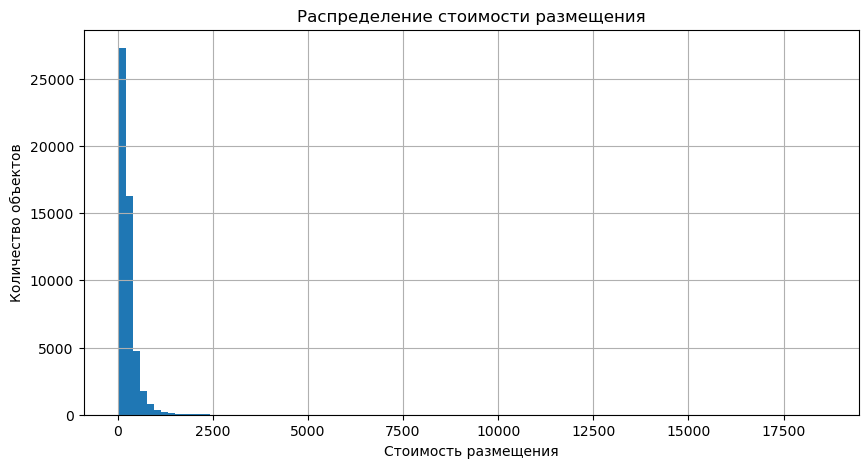

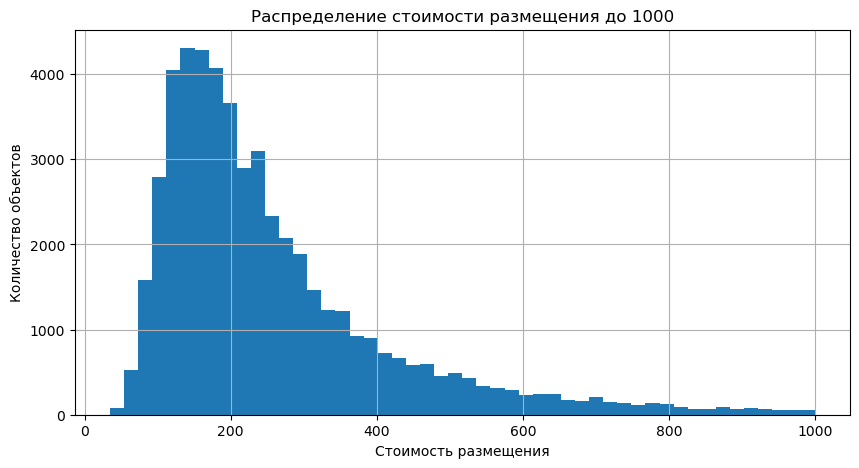

In [105]:
# Построим гистограммы распределения стоимости размещения `realSum`: 
# сначала по всем значениям, затем отдельно для основной массы объектов со стоимостью до 1000.

airbnb['realSum'].hist(bins=100, figsize=(10, 5))
plt.title('Распределение стоимости размещения')
plt.xlabel('Стоимость размещения')
plt.ylabel('Количество объектов');

plt.figure()

airbnb[airbnb['realSum'] <= 1000]['realSum'].hist(bins=50, figsize=(10, 5));
plt.title('Распределение стоимости размещения до 1000')
plt.xlabel('Стоимость размещения')
plt.ylabel('Количество объектов');

Гистограммы используются как первичный обзор распределения `realSum`. По общему графику видно, что в данных есть очень дорогие предложения, из-за которых основная часть значений визуально сжата слева. Поэтому дальше распределение цен и выбросы будут анализироваться подробнее по городам и периодам, а не только по всему датасету сразу.

Сравним среднюю и медианную стоимость размещения по городам. Медиана используется как более устойчивый показатель типичной цены, а среднее и максимальное значение помогают увидеть влияние дорогих объектов.

In [106]:
price_by_city = (
    airbnb
    .groupby('city')
    .agg(
        count=('realSum', 'count'),           # количество наблюдений
        mean_price=('realSum', 'mean'),       # средняя стоимость
        median_price=('realSum', 'median'),   # медианная стоимость
        min_price=('realSum','min'),          # минимальная стоимость
        max_price=('realSum', 'max')          # максимальная стоимость
    )
    .sort_values('median_price')              # сортировка от более дешевых городов к более дороги
    .round(2)                                 # округление значений до 2 знаков
)

display(price_by_city)

,count,mean_price,median_price,min_price,max_price
city,,,,,
athens,5280,151.74,127.72,42.88,18545.45
budapest,4022,176.51,152.98,34.78,3751.23
rome,9027,205.39,182.59,46.06,2418.35
berlin,2484,244.58,191.18,64.97,5857.48
barcelona,2833,293.75,208.30,69.59,6943.70
vienna,3537,241.58,208.49,63.58,13664.31
lisbon,5763,238.21,225.38,70.59,1681.05
london,9993,362.47,261.29,54.33,15499.89
paris,6688,392.53,317.60,92.74,16445.61


По медианной стоимости размещения самыми доступными городами являются Афины, Будапешт и Рим. Самыми дорогими городами являются Лондон, Париж и Амстердам, при этом Амстердам заметно выделяется максимальной медианной стоимостью.

Во всех городах средняя стоимость выше медианной, что подтверждает влияние дорогих объектов на распределение цен. Особенно заметна разница между средним и медианой в Амстердаме, Париже, Лондоне, Барселоне и Вене. Поэтому для сравнения типичной стоимости размещения между городами медиана подходит лучше, чем среднее значение.

Построим boxplot стоимости размещения по городам, чтобы визуально сравнить распределение цен и увидеть наличие дорогих выбросов.

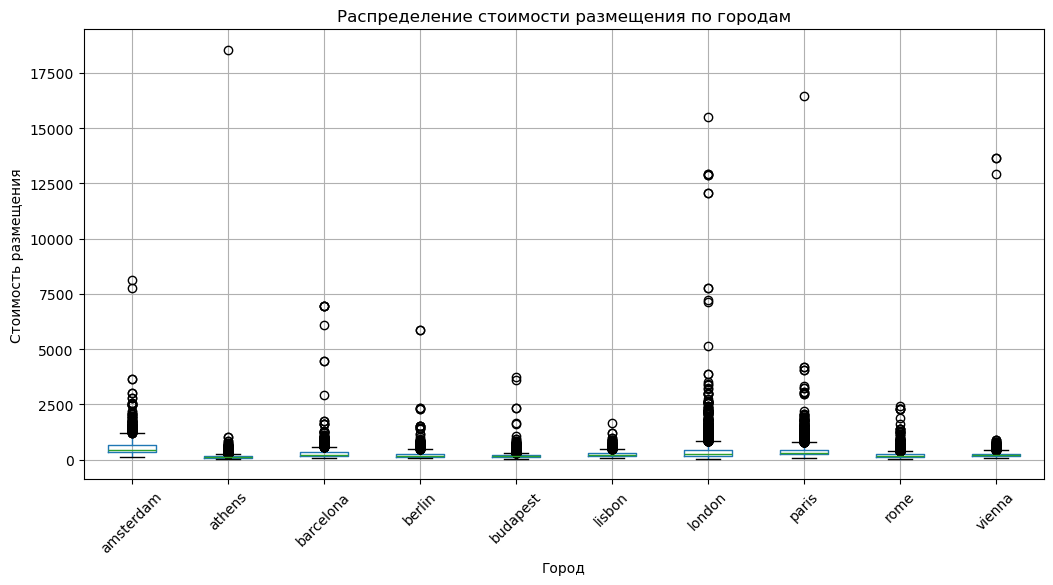

In [107]:
airbnb.boxplot(
    column='realSum',
    by='city',
    figsize=(12,6),
    rot=45
)

plt.title('Распределение стоимости размещения по городам')
plt.suptitle('')
plt.xlabel('Город')
plt.ylabel('Стоимость размещения');

Boxplot показывает большое количество дорогих выбросов почти во всех городах. Эти значения не удаляются автоматически, так как в контексте Airbnb они могут отражать реальные дорогие объекты, а не ошибки данных. При этом из-за их влияния средняя стоимость может быть завышена, поэтому для сравнения типичной цены размещения далее основным показателем будет использоваться медиана.

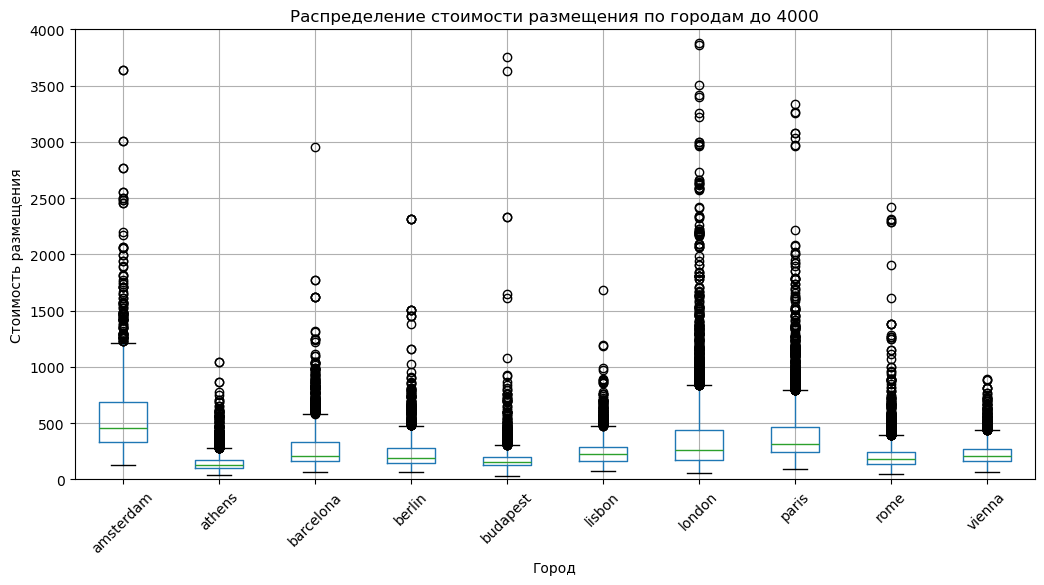

In [108]:
airbnb.boxplot(
    column='realSum',
    by='city',
    figsize=(12,6),
    rot=45
)

plt.title('Распределение стоимости размещения по городам до 4000')
plt.suptitle('')
plt.xlabel('Город')
plt.ylabel('Стоимость размещения')
plt.ylim(0, 4000);

На boxplot видно, что распределение стоимости размещения заметно отличается между городами. Самые высокие медианные значения наблюдаются в Амстердаме, Париже и Лондоне, а самые низкие — в Афинах и Будапеште.

Во всех городах присутствуют дорогие выбросы, особенно заметные в Амстердаме, Лондоне и Париже. При этом ограничение оси Y до 4000 используется только для читаемости графика и не удаляет эти значения из данных.

Рассчитаем выбросы по стоимости размещения методом IQR отдельно для каждой пары `city + period`. Левые и правые выбросы считаются отдельно, так как для туристической задачи они имеют разный смысл: необычно дешевые объекты могут быть потенциально интересны для экономии, а необычно дорогие показывают премиальный сегмент и могут завышать средние значения.

In [109]:
# Функция считает границы выбросов по IQR и долю выбросов внутри одной группы

def iqr_outlier_stats(group):
    q1 = group['realSum'].quantile(0.25)  # первый квартиль
    q3 = group['realSum'].quantile(0.75)  # третий квартиль
    iqr = q3 - q1                         # межквартильный размах

    lower_bound = q1 - 1.5 * iqr          # нижняя граница выбросов
    upper_bound = q3 + 1.5 * iqr          # верхняя граница выбросов

    low_outliers = group['realSum'] < lower_bound    # необычно дешевые объекты
    high_outliers = group['realSum'] > upper_bound   # необычно дорогие объекты

    return pd.Series({
        'count': group['realSum'].count(),
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'low_outliers_count': low_outliers.sum(),
        'high_outliers_count': high_outliers.sum(),
        'low_outliers_share': low_outliers.mean() * 100,
        'high_outliers_share': high_outliers.mean() * 100
    })

# Применяю функцию к каждой группе город + период

outliers_by_city_period = (
    airbnb
    .groupby(['city', 'period'])
    .apply(iqr_outlier_stats, include_groups=False)
    .round(2)
    .sort_values('high_outliers_share', ascending=False)
)

display(outliers_by_city_period)

count      q1      q3     iqr  lower_bound  upper_bound  \
city      period                                                               
barcelona weekends  1278.0  159.66  327.17  167.51       -91.61       578.44   
          weekdays  1555.0  161.98  335.37  173.39       -98.10       595.46   
berlin    weekdays  1284.0  143.73  277.01  133.27       -56.18       476.92   
          weekends  1200.0  147.24  286.76  139.53       -62.05       496.05   
paris     weekdays  3130.0  240.00  463.46  223.46       -95.19       798.65   
budapest  weekdays  2074.0  122.43  184.94   62.51        28.67       278.70   
athens    weekdays  2653.0   99.59  171.54   71.94        -8.32       279.45   
amsterdam weekends   977.0  362.76  716.61  353.85      -168.02      1247.39   
budapest  weekends  1948.0  128.25  208.97   80.72         7.17       330.05   
london    weekends  5379.0  174.51  438.27  263.76      -221.14       833.92   
athens    weekends  2627.0   98.66  171.54   72.88       -10.66       280.86   
paris     weekends  3558.0  240.99  461.13  220.14       -89.21       791.34   
london    weekdays  4614.0  167.45  435.45  268.00      -234.54       837.45   
amsterdam weekdays  1103.0  309.80  657.32  347.53      -211.49      1178.61   
rome      weekdays  4492.0  136.07  235.20   99.13       -12.62       383.89   
          weekends  4535.0  138.64  242.68  104.04       -17.42       398.73   
vienna    weekdays  1738.0  162.21  266.64  104.42         5.58       423.27   
          weekends  1799.0  165.14  280.02  114.88        -7.19       452.34   
lisbon    weekends  2906.0  161.82  289.34  127.52       -29.46       480.62   
          weekdays  2857.0  160.18  284.01  123.83       -25.56       469.75   

                    low_outliers_count  high_outliers_count  \
city      period                                              
barcelona weekends                 0.0                103.0   
          weekdays                 0.0                117.0   
berlin    weekdays                 0.0                 81.0   
          weekends                 0.0                 74.0   
paris     weekdays                 0.0                192.0   
budapest  weekdays                 0.0                123.0   
athens    weekdays                 0.0                153.0   
amsterdam weekends                 0.0                 55.0   
budapest  weekends                 0.0                108.0   
london    weekends                 0.0                297.0   
athens    weekends                 0.0                142.0   
paris     weekends                 0.0                191.0   
london    weekdays                 0.0                247.0   
amsterdam weekdays                 0.0                 56.0   
rome      weekdays                 0.0                226.0   
          weekends                 0.0                227.0   
vienna    weekdays                 0.0                 74.0   
          weekends                 0.0                 74.0   
lisbon    weekends                 0.0                101.0   
          weekdays                 0.0                 96.0   

                    low_outliers_share  high_outliers_share  
city      period                                             
barcelona weekends                 0.0                 8.06  
          weekdays                 0.0                 7.52  
berlin    weekdays                 0.0                 6.31  
          weekends                 0.0                 6.17  
paris     weekdays                 0.0                 6.13  
budapest  weekdays                 0.0                 5.93  
athens    weekdays                 0.0                 5.77  
amsterdam weekends                 0.0                 5.63  
budapest  weekends                 0.0                 5.54  
london    weekends                 0.0                 5.52  
athens    weekends                 0.0                 5.41  
paris     weekends                 0.0                 5.37  
londo

Расчет по IQR показывает, что левых выбросов по стоимости размещения в группах не обнаружено: необычно дешевые объекты относительно своих городов и периодов не выделяются по этому правилу. Все выявленные выбросы относятся к правому хвосту распределения, то есть к необычно дорогим предложениям.

Наибольшая доля дорогих выбросов наблюдается в Барселоне: около 8.06% в выходные и 7.52% в будни. Также заметная доля правых выбросов есть в Берлине, Париже, Будапеште и Афинах. В Лиссабоне доля дорогих выбросов ниже остальных городов — около 3.36–3.48%.

Так как дорогие выбросы присутствуют во всех городах и периодах, удалять их автоматически не стоит: они могут отражать реальные премиальные или крупные объекты. При этом для сравнения типичной стоимости размещения лучше использовать медиану, так как она менее чувствительна к правому хвосту распределения.

## 4. Сравнить среднюю и медианную стоимость размещения

На этом этапе сравним среднюю и медианную стоимость размещения по городам. Это нужно, чтобы выбрать основной показатель для дальнейшего анализа типичной цены.

In [110]:
# Сравниваю среднюю и медианную стоимость размещения по городам

mean_median_comparison = price_by_city.copy()

# Считаю абсолютную разницу между средней и медианной стоимостью

mean_median_comparison['mean_minus_median'] = (
    mean_median_comparison['mean_price'] - mean_median_comparison['median_price']
)

mean_median_comparison['mean_median_diff_percent']=(
    mean_median_comparison['mean_minus_median'] / mean_median_comparison['median_price'] * 100
)

mean_median_comparison = (
    mean_median_comparison
    .sort_values('mean_median_diff_percent', ascending=False)
    .round(2)
)

display(mean_median_comparison)

,count,mean_price,median_price,min_price,max_price,mean_minus_median,mean_median_diff_percent
city,,,,,,,
barcelona,2833,293.75,208.30,69.59,6943.70,85.45,41.02
london,9993,362.47,261.29,54.33,15499.89,101.18,38.72
berlin,2484,244.58,191.18,64.97,5857.48,53.40,27.93
amsterdam,2080,573.11,460.24,128.89,8130.67,112.87,24.52
paris,6688,392.53,317.60,92.74,16445.61,74.93,23.59
athens,5280,151.74,127.72,42.88,18545.45,24.02,18.81
vienna,3537,241.58,208.49,63.58,13664.31,33.09,15.87
budapest,4022,176.51,152.98,34.78,3751.23,23.53,15.38
rome,9027,205.39,182.59,46.06,2418.35,22.80,12.49


Во всех городах средняя стоимость размещения выше медианной. Это означает, что в распределении цен есть дорогие объекты, которые смещают среднее значение вверх.

Наибольшая относительная разница между средним и медианой наблюдается в Барселоне, Лондоне и Берлине. В этих городах средняя цена особенно чувствительна к дорогим предложениям. Наименьшая разница наблюдается в Лиссабоне, где среднее значение ближе к медиане.

Поэтому для дальнейшего сравнения типичной стоимости размещения между городами основным показателем будет использоваться медиана, а среднее значение будет рассматриваться как дополнительный показатель.

Сравним города по медианной стоимости размещения. Так как ранее было показано, что среднее значение чувствительно к дорогим объектам, для сравнения типичной стоимости используем медиану.

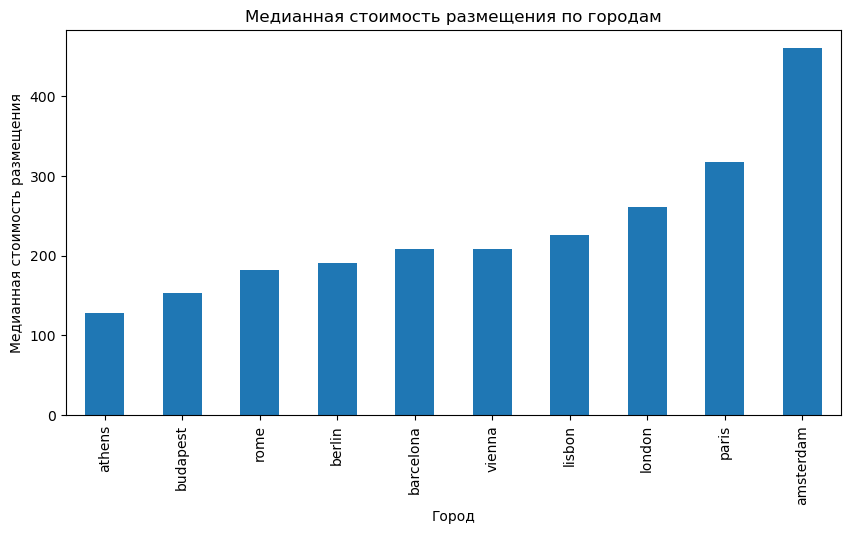

In [113]:
# Сравниваю города по медианной стоимости размещения

price_by_city['median_price'].sort_values().plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Медианная стоимость размещения по городам')
plt.xlabel('Город')
plt.ylabel('Медианная стоимость размещения');

По медианной стоимости размещения самым доступным городом являются Афины, далее идут Будапешт и Рим. Самые дорогие города — Амстердам, Париж и Лондон. Особенно заметно выделяется Амстердам: его медианная стоимость размещения значительно выше остальных городов.

Дополнительно рассчитаем, насколько медианная стоимость размещения в каждом городе выше минимальной медианной стоимости в выборке. За базовый уровень примем самый дешевый город — Афины.

In [114]:
# Считаю, насколько медианная стоимость в каждом городе выше минимальной медианной стоимости

city_price_comparison = price_by_city[['median_price']].copy()

min_median_price = city_price_comparison['median_price'].min()

city_price_comparison['difference_from_cheapest'] = (
    city_price_comparison['median_price'] - min_median_price
)

city_price_comparison['difference_from_cheapest_percent'] = (
    city_price_comparison['difference_from_cheapest'] / min_median_price * 100
)

city_price_comparison = city_price_comparison.round(2)

display(city_price_comparison)

,median_price,difference_from_cheapest,difference_from_cheapest_percent
city,,,
athens,127.72,0.00,0.00
budapest,152.98,25.26,19.78
rome,182.59,54.87,42.96
berlin,191.18,63.46,49.69
barcelona,208.30,80.58,63.09
vienna,208.49,80.77,63.24
lisbon,225.38,97.66,76.46
london,261.29,133.57,104.58
paris,317.60,189.88,148.67


Если принять Афины за самый доступный город в выборке, то Будапешт дороже примерно на 19.78%, а Рим — на 42.96%. Эти города можно отнести к более бюджетным направлениям.

Берлин, Барселона, Вена и Лиссабон находятся в среднем ценовом диапазоне: их медианная стоимость выше Афин примерно на 49.69–76.46%.

Самые дорогие направления — Лондон, Париж и Амстердам. Лондон дороже Афин примерно на 104.58%, Париж — на 148.67%, а Амстердам — на 260.35%. Поэтому с точки зрения типичной стоимости размещения наиболее выгодными городами выглядят Афины, Будапешт и Рим, а наиболее дорогим вариантом является Амстердам.

# ОСТАНОВИЛСЯ ЗДЕСЬ

Даьлше относиться к 6 части

ВАЖНО: ИЗМЕНИТЬ ТЕКСТ КОГДА ДОЙДЕТ ДЕЛО ЖО ЭТОЙ ЯЧЕЙКИ 
Дополнительно сравним стоимость размещения по городам отдельно для будних и выходных дней. Это позволит увидеть, насколько различается типичная цена между периодами внутри каждого города. 

In [111]:
# Группирую данные по городу и периоду, чтобы сравнить цены в будни и выходные

price_by_city_period = (
    airbnb
    .groupby(['city', 'period'])
    .agg(
        count=('realSum', 'count'),           # количество наблюдений
        mean_price=('realSum', 'mean'),       # средняя стоимость
        median_price=('realSum', 'median'),   # медианная стоимость
        min_price=('realSum','min'),          # минимальная стоимость
        max_price=('realSum', 'max')          # максимальная стоимость
    )
    .sort_values(['city', 'period'])          # сортировка по городу и период
    .round(2)                                 # округление значений до 2 знаков
)

display(price_by_city_period)

count  mean_price  median_price  min_price  max_price
city      period                                                         
amsterdam weekdays   1103      545.02        430.25     128.89    7782.91
          weekends    977      604.83        491.65     165.91    8130.67
athens    weekdays   2653      155.87        127.72      42.88   18545.45
          weekends   2627      147.58        127.72      42.88    1043.28
barcelona weekdays   1555      288.39        208.53      69.59    6943.70
          weekends   1278      300.28        204.69      80.99    6942.77
berlin    weekdays   1284      240.22        187.79      64.97    5857.48
          weekends   1200      249.25        192.46      64.97    5856.08
budapest  weekdays   2074      168.43        147.46      37.13    3630.68
          weekends   1948      185.12        160.03      34.78    3751.23
lisbon    weekdays   2857      236.35        223.03      70.83    1681.05
          weekends   2906      240.04        227.72      70.59    1188.09
london    weekdays   4614      360.23        256.36      64.68   15499.89
          weekends   5379      364.39        268.12      54.33   12937.28
paris     weekdays   3130      398.79        318.53      92.74   16445.61
          weekends   3558      387.03        316.20      95.30    4188.41
rome      weekdays   4492      201.62        179.79      46.06    2418.35
          weekends   4535      209.13        184.46      46.06    2311.74
vienna    weekdays   1738      240.38        204.52      69.65   13664.31
          weekends   1799      242.74        212.00      63.58   13656.36

ВАЖНО: ИЗМЕНИТЬ ТЕКСТ КОГДА ДОЙДЕТ ДЕЛО ЖО ЭТОЙ ЯЧЕЙКИ При сравнении будних и выходных дней видно, что различия в медианной стоимости внутри большинства городов есть, но они не всегда большие. В Амстердаме, Будапеште, Лондоне, Лиссабоне, Риме и Вене медианная цена в выходные выше, чем в будни. В Барселоне и Париже медианная цена в выходные немного ниже, а в Афинах медиана практически не меняется.

При этом средние значения во многих городах заметно выше медианных, что снова указывает на влияние дорогих объектов. Поэтому для дальнейшего сравнения периодов основной показатель также лучше строить на медианной стоимости.

ВАЖНО: ИЗМЕНИТЬ ТЕКСТ КОГДА ДОЙДЕТ ДЕЛО ЖО ЭТОЙ ЯЧЕЙКИ 
Рассчитаем разницу медианной стоимости между выходными и будними днями по каждому городу. Положительное значение показывает, что в выходные медианная стоимость выше, отрицательное — что ниже.

In [112]:
# Считаю медианную стоимость размещения по городам и периодам

median_price_by_period = (
    airbnb
    .groupby(['city', 'period'])['realSum']
    .median()
    .unstack('period')   # разворачиваю значения period в отдельные колонки weekdays и weekends
)

# Считаю разницу между выходными и будними днями в абсолютном значении

median_price_by_period['difference'] = (
    median_price_by_period['weekends'] - median_price_by_period['weekdays']
)

# Считаю разницу в процентах относительно стоимости в будни

median_price_by_period['difference_percent'] = (
    median_price_by_period['difference'] / median_price_by_period['weekdays'] * 100
)

median_price_by_period = median_price_by_period.round(2)

display(median_price_by_period.sort_values('difference_percent', ascending=False))

period,weekdays,weekends,difference,difference_percent
city,,,,
amsterdam,430.25,491.65,61.40,14.27
budapest,147.46,160.03,12.57,8.53
london,256.36,268.12,11.76,4.59
vienna,204.52,212.00,7.48,3.66
rome,179.79,184.46,4.68,2.60
berlin,187.79,192.46,4.67,2.49
lisbon,223.03,227.72,4.69,2.10
athens,127.72,127.72,0.00,0.00
paris,318.53,316.20,-2.33,-0.73


ВАЖНО: ИЗМЕНИТЬ ТЕКСТ КОГДА ДОЙДЕТ ДЕЛО ЖО ЭТОЙ ЯЧЕЙКИ Наиболее заметное увеличение медианной стоимости в выходные наблюдается в Амстердаме: цена выше примерно на 14.27%. Также заметная разница есть в Будапеште, где выходные дороже примерно на 8.53%.

Для Лондона и Вены рост цены в выходные умеренный: примерно 4.59% и 3.66% соответственно. Эти города могут быть чувствительны к выбору периода, но разница уже не такая резкая.

В Риме, Берлине и Лиссабоне разница между выходными и буднями небольшая — до 2.5%. Афины, Париж и Барселона также можно отнести к городам, где период недели почти не влияет на типичную стоимость размещения: в Афинах медианная цена не изменилась, а в Париже и Барселоне в выходные медиана даже немного ниже.

С точки зрения туриста, сильнее всего учитывать день недели стоит при поездке в Амстердам и Будапешт. В городах с разницей до 2.5% поездка в выходные выглядит приемлемой по стоимости размещения.